In [1]:
import pickle
import random

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
data = pd.read_csv("Clean_Data.csv")
data = data.dropna(subset=["cleaned_text", "sentiment"]).copy()
data["sentiment"] = data["sentiment"].astype(int)
data["cleaned_text"] = data["cleaned_text"].astype(str)

print(data.shape)
print(data["sentiment"].value_counts().sort_index())
data.head()


(17755, 3)
sentiment
0    5723
1    6237
2    5795
Name: count, dtype: int64


,text,sentiment,cleaned_text
0,i just feel really helpless and heavy hearted,0,feel really helpless heavy hearted
1,ive enjoyed being able to slouch about relax a...,0,ive enjoyed able slouch relax unwind frankly n...
2,i gave up my internship with the dmrg and am f...,0,gave internship dmrg feeling distraught
3,i dont know i feel so lost,0,dont know feel lost
4,i am a kindergarten teacher and i am thoroughl...,0,kindergarten teacher thoroughly weary job take...


In [ ]:
texts = data["cleaned_text"].values
labels = data["sentiment"].values

MAX_WORDS = 30000
MAX_LEN = 80
EMBEDDING_DIM = 128
NUM_CLASSES = 3

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=SEED, stratify=labels,)

X_train_text, X_val_text, y_train, y_val = train_test_split(X_train_text, y_train,test_size=0.15, random_state=SEED, stratify=y_train,)


In [5]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding="post", truncating="post")
X_val = pad_sequences(tokenizer.texts_to_sequences(X_val_text), maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("vocab_size:", vocab_size)
print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)


vocab_size: 13817
train/val/test: (12073, 80) (2131, 80) (3551, 80)


In [6]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True),
    SpatialDropout1D(0.25),
    Bidirectional(LSTM(96, return_sequences=True, dropout=0.25)),
    Bidirectional(LSTM(48, dropout=0.25)),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5),
    ModelCheckpoint("sentiment_model.keras", monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
)


Epoch 1/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 59s 265ms/step - accuracy: 0.5723 - loss: 0.8847 - val_accuracy: 0.7372 - val_loss: 0.6487 - learning_rate: 0.0010
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 44s 232ms/step - accuracy: 0.8400 - loss: 0.4258 - val_accuracy: 0.7780 - val_loss: 0.6127 - learning_rate: 0.0010
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 45s 237ms/step - accuracy: 0.9204 - loss: 0.2353 - val_accuracy: 0.7851 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 4/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 46s 242ms/step - accuracy: 0.9550 - loss: 0.1433 - val_accuracy: 0.8085 - val_loss: 0.7822 - learning_rate: 5.0000e-04
Epoch 5/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 45s 240ms/step - accuracy: 0.9655 - loss: 0.1020 - val_accuracy: 0.8048 - val_loss: 0.8276 - learning_rate: 2.5000e-04
Epoch 6/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 274ms/step - accuracy: 0.9736 - loss: 0.0828 - val_accuracy: 0.8053 - val_loss: 0.8693 - learning_rate: 1.2500e-04
Epoch 7/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 55s 292ms/step - a

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {accuracy:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))
print(confusion_matrix(y_test, y_pred))


Test accuracy: 0.7978
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
              precision    recall  f1-score   support

    Negative       0.79      0.83      0.81      1145
     Neutral       0.78      0.77      0.77      1247
    Positive       0.82      0.80      0.81      1159

    accuracy                           0.80      3551
   macro avg       0.80      0.80      0.80      3551
weighted avg       0.80      0.80      0.80      3551

[[954 116  75]
 [166 954 127]
 [ 83 151 925]]


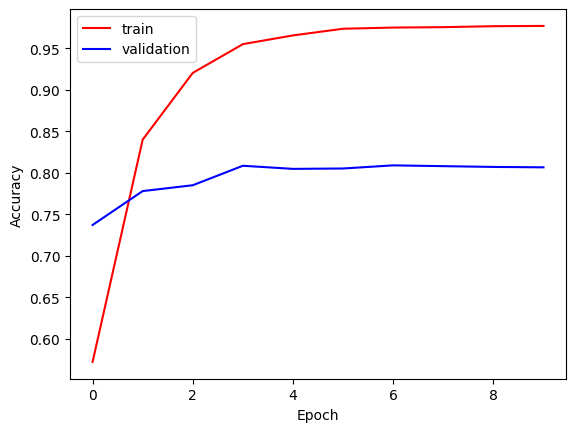

In [9]:
plt.plot(history.history["accuracy"], color="red", label="train")
plt.plot(history.history["val_accuracy"], color="blue", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


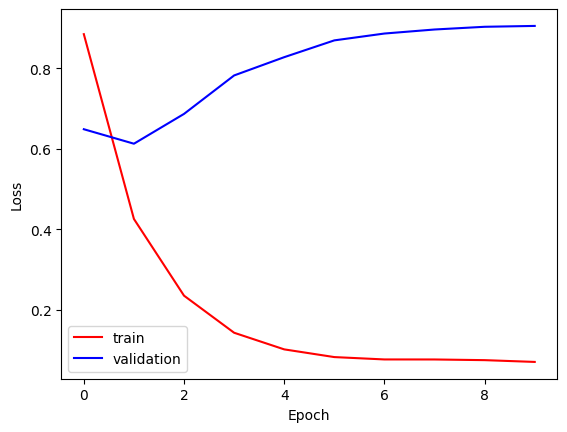

In [10]:
plt.plot(history.history["loss"], color="red", label="train")
plt.plot(history.history["val_loss"], color="blue", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [11]:
model.save("sentiment_model.h5")
model.save("sentiment_model.keras")

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)


In [12]:
def predict_sentiment(text, model, tokenizer, maxlen=MAX_LEN):
    label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
    sequence = tokenizer.texts_to_sequences([str(text)])
    padded_sequence = pad_sequences(sequence, maxlen=maxlen, padding="post", truncating="post")
    probabilities = model.predict(padded_sequence, verbose=0)[0]
    predicted_label = int(np.argmax(probabilities))
    return label_names[predicted_label], float(probabilities[predicted_label])


In [13]:
new_text = input("Your text here: ")
sentiment, confidence = predict_sentiment(new_text, model, tokenizer)
print(f"Predicted Sentiment: {sentiment} ({confidence:.2%})")


Predicted Sentiment: Negative (79.83%)
